In [2]:
# @title Install & Imports
!pip -q install pandas numpy scikit-learn matplotlib joblib statsmodels

import os, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from joblib import dump, load
import matplotlib.pyplot as plt

from google.colab import files


In [7]:
!pip -q install pandas numpy scikit-learn matplotlib joblib

import json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from joblib import dump

In [8]:
print("📤 Choose Health_Risk_Dataset.csv to upload...")
uploaded = files.upload()
assert uploaded, "No file uploaded."
csv_path = list(uploaded.keys())[0]
df = pd.read_csv(csv_path)
print("✅ Loaded:", csv_path, "shape:", df.shape)
print("Columns:", df.columns.tolist())

📤 Choose Health_Risk_Dataset.csv to upload...


Saving Health_Risk_Dataset.csv to Health_Risk_Dataset (1).csv
✅ Loaded: Health_Risk_Dataset (1).csv shape: (1000, 10)
Columns: ['Patient_ID', 'Respiratory_Rate', 'Oxygen_Saturation', 'O2_Scale', 'Systolic_BP', 'Heart_Rate', 'Temperature', 'Consciousness', 'On_Oxygen', 'Risk_Level']


In [9]:
TARGET = "Risk_Level"
CANDIDATE_FEATURES = [
    # numeric core vitals/labs
    "Age","BMI","BP","Glucose","Cholesterol","HeartRate","Steps","SleepHours","Temperature",
    # risk flags / conditions (often numeric/binary but may be object)
    "Hypertension","Diabetes","On_Oxygen","Consciousness",
    # lifestyle / family / demographics
    "Smoking","AlcoholIntake","PhysicalActivity","FamilyHistory","Gender"
]

# Keep only those that exist in the file
FEATURES = [c for c in CANDIDATE_FEATURES if c in df.columns]
missing = [c for c in CANDIDATE_FEATURES if c not in df.columns]
if missing:
    print("ℹ️ These candidate features were not found and will be skipped:", missing)

# Safety: ensure target exists
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Available columns: {df.columns.tolist()}")

X = df[FEATURES].copy()
y = df[TARGET].copy()

ℹ️ These candidate features were not found and will be skipped: ['Age', 'BMI', 'BP', 'Glucose', 'Cholesterol', 'HeartRate', 'Steps', 'SleepHours', 'Hypertension', 'Diabetes', 'Smoking', 'AlcoholIntake', 'PhysicalActivity', 'FamilyHistory', 'Gender']


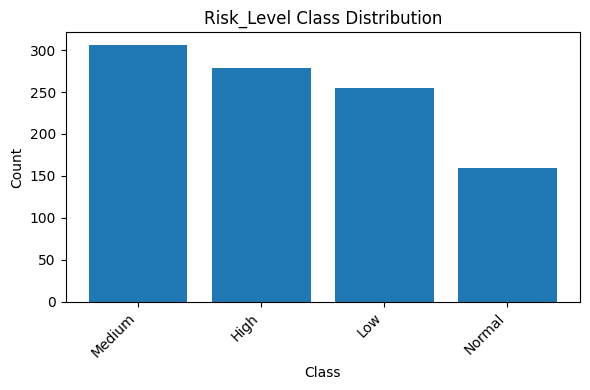

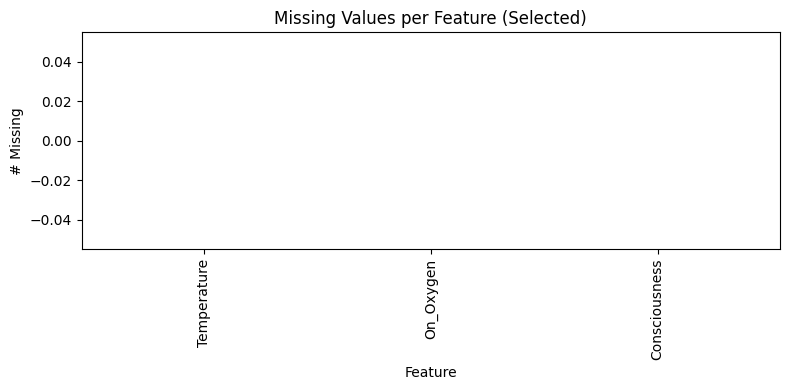

In [10]:
plt.figure(figsize=(6,4))
counts = y.value_counts(dropna=False)
plt.bar(counts.index.astype(str), counts.values)
plt.title("Risk_Level Class Distribution")
plt.xlabel("Class"); plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
nulls = X.isna().sum().sort_values(ascending=False)
plt.bar(nulls.index.astype(str), nulls.values)
plt.title("Missing Values per Feature (Selected)")
plt.xlabel("Feature"); plt.ylabel("# Missing")
plt.xticks(rotation=90)
plt.tight_layout(); plt.show()

✅ Accuracy: 0.9250 | F1-weighted: 0.9253

Classification Report:
               precision    recall  f1-score   support

        High       0.96      0.96      0.96        56
         Low       0.90      0.88      0.89        51
      Medium       0.88      0.92      0.90        61
      Normal       1.00      0.94      0.97        32

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



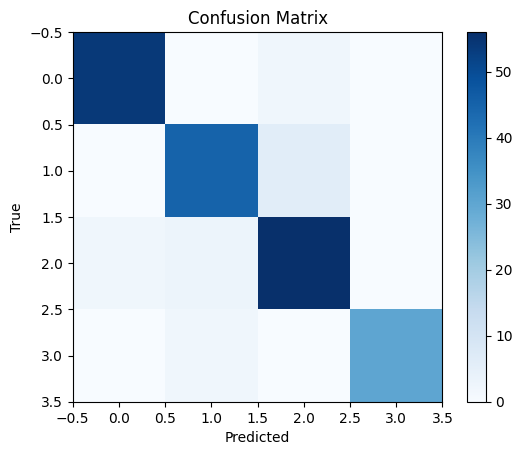

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
!pip -q install imbalanced-learn

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from joblib import dump
TARGET = "Risk_Level"   # adjust if your target column has different name
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Detect column types
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Preprocessing
num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_tf, num_cols),
    ("cat", cat_tf, cat_cols)
])

# Model with SMOTE
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

pipe = ImbPipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("clf", rf)
])

# Train
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, preds)
f1w = f1_score(y_test, preds, average="weighted")
print(f"✅ Accuracy: {acc:.4f} | F1-weighted: {f1w:.4f}")
print("\nClassification Report:\n", classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

# Save model
dump(pipe, "health_risk_rf_smote.joblib")
files.download("health_risk_rf_smote.joblib")